# One-Pixel Attack: How Few Pixels Does It Take?

Every attack in `attacks/whitebox/` and the rest of `attacks/blackbox/` bounds its perturbation by how *large* the change to each pixel can be ($L_\infty$/$L_2$). Su et al. (2019, *"One Pixel Attack for Fooling Deep Neural Networks"*) bound it a completely different way: by how *many* pixels can change at all ($L_0$), with no limit on how much a changed pixel's color can move. It is also decision-based like Boundary Attack, no gradients, no confidence scores beyond what the search itself queries for, found with **differential evolution** (Storn & Price, 1997), a population-based, gradient-free optimizer: a population of candidate pixel edits is evolved generation by generation, keeping whichever mutation of each candidate lowers the true class's probability the most.

At CIFAR-10 resolution (32x32, ~1,000 pixels), a single changed pixel is already a non-trivial fraction of the image and the original paper reports a real, if modest, success rate. Every other model in this repo works at 224x224 or 299x299, tens of thousands of pixels; a single one of them is a vastly smaller fraction of the input, a genuinely different, harder regime to attack in. This notebook measures the gap directly, sweeping how many pixels are allowed to change.

In [1]:
import tensorflow as tf
import numpy as np
import glob
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution

from tensorflow.keras.applications import MobileNetV2, InceptionV3
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mob, decode_predictions as decode_mob
from tensorflow.keras.applications.inception_v3 import preprocess_input as preprocess_inc, decode_predictions as decode_inc

np.random.seed(0)
tf.random.set_seed(0)

### Setup
Two models instead of three, and a smaller image sample than most other notebooks in this repo:
differential evolution needs many forward passes per image (population size x generations), so cost
scales with model count x image count in a way gradient-based attacks do not.

In [2]:
models_dict = {
    'MobileNetV2': {
        'model': MobileNetV2(weights='imagenet'), 'target_size': (224, 224),
        'preprocess_fn': preprocess_mob, 'decode_fn': decode_mob,
    },
    'InceptionV3': {
        'model': InceptionV3(weights='imagenet'), 'target_size': (299, 299),
        'preprocess_fn': preprocess_inc, 'decode_fn': decode_inc,
    },
}
for config in models_dict.values():
    config['model'].trainable = False

def load_raw_image(img_path, target_size):
    """Returns a float32 array in raw [0, 255] RGB, the natural space to describe 'one pixel'
    edits in; model-specific preprocessing is applied only at prediction time."""
    img_raw = tf.io.read_file(img_path)
    img = tf.image.decode_image(img_raw, channels=3)
    img = tf.image.resize(tf.cast(img, tf.float32), target_size)
    return img.numpy()

NUM_IMAGES = 8
image_paths = sorted(glob.glob('../../images/miniimagenet_random_100/*.*'))[:NUM_IMAGES]
print(f"Using {len(image_paths)} images across {len(models_dict)} models")

Using 8 images across 2 models


### The Attack
`perturb_pixels` applies a flat vector of `(x, y, r, g, b)` tuples on top of the raw image;
`predict_true_class_prob` is the fitness function differential evolution minimizes, the true
class's softmax probability after the edit, no gradient involved anywhere in this cell.

In [3]:
def perturb_pixels(raw_img, pixel_params):
    img = raw_img.copy()
    n_pixels = len(pixel_params) // 5
    for i in range(n_pixels):
        x, y, r, g, b = pixel_params[i * 5:i * 5 + 5]
        img[int(y), int(x)] = [r, g, b]
    return img

def predict(raw_img, preprocess_fn, model):
    x = preprocess_fn(np.expand_dims(raw_img, 0).copy())
    return model(x, training=False).numpy()[0]

def true_class_prob(pixel_params, raw_img, true_idx, preprocess_fn, model):
    candidate = perturb_pixels(raw_img, pixel_params)
    return predict(candidate, preprocess_fn, model)[true_idx]

def one_pixel_attack(raw_img, true_idx, preprocess_fn, model, n_pixels, target_size, popsize=10, maxiter=40):
    h, w = target_size
    bounds = [(0, w - 1), (0, h - 1), (0, 255), (0, 255), (0, 255)] * n_pixels

    def stop_if_fooled(xk, convergence):
        candidate = perturb_pixels(raw_img, xk)
        pred_idx = int(np.argmax(predict(candidate, preprocess_fn, model)))
        return pred_idx != true_idx

    result = differential_evolution(
        true_class_prob, bounds, args=(raw_img, true_idx, preprocess_fn, model),
        popsize=popsize, maxiter=maxiter, callback=stop_if_fooled, polish=False, seed=0,
    )
    adv_img = perturb_pixels(raw_img, result.x)
    adv_idx = int(np.argmax(predict(adv_img, preprocess_fn, model)))
    return adv_img, adv_idx, result.x

### Sweeping the Pixel Budget
1, 3, and 5 pixels, across both models and every image already correctly classified. The upper end
(5 pixels) is still an extraordinarily small edit at 224x224+ resolution, roughly 0.01% of the
image's pixels, nowhere near the fraction a CIFAR-10-scale one-pixel attack changes.

In [4]:
N_PIXELS_VALUES = [1, 3, 5]

rows = []
for model_name, m_config in models_dict.items():
    print(f"\n{'='*80}\nMODEL: {model_name}\n{'='*80}")
    model, preprocess_fn, target_size = m_config['model'], m_config['preprocess_fn'], m_config['target_size']

    for img_path in image_paths:
        raw_img = load_raw_image(img_path, target_size)
        true_idx = int(np.argmax(predict(raw_img, preprocess_fn, model)))

        for n_pixels in N_PIXELS_VALUES:
            adv_img, adv_idx, _ = one_pixel_attack(raw_img, true_idx, preprocess_fn, model, n_pixels, target_size)
            rows.append({
                'Model': model_name, 'N_Pixels': n_pixels,
                'Success': adv_idx != true_idx,
            })
        print(f"  {img_path.split('/')[-1]}: done")

results_df = pd.DataFrame(rows)
results_df.to_csv('one_pixel_results.csv', index=False)
summary = results_df.groupby(['Model', 'N_Pixels'])['Success'].mean().unstack() * 100
summary.round(1)


MODEL: MobileNetV2
  miniimagenet_random_100\n01532829.jpg: done
  miniimagenet_random_100\n01558993.jpg: done
  miniimagenet_random_100\n01704323.jpg: done
  miniimagenet_random_100\n01749939.jpg: done
  miniimagenet_random_100\n01770081.jpg: done
  miniimagenet_random_100\n01843383.jpg: done
  miniimagenet_random_100\n01855672.jpg: done
  miniimagenet_random_100\n01910747.jpg: done

MODEL: InceptionV3
  miniimagenet_random_100\n01532829.jpg: done
  miniimagenet_random_100\n01558993.jpg: done
  miniimagenet_random_100\n01704323.jpg: done
  miniimagenet_random_100\n01749939.jpg: done
  miniimagenet_random_100\n01770081.jpg: done
  miniimagenet_random_100\n01843383.jpg: done
  miniimagenet_random_100\n01855672.jpg: done
  miniimagenet_random_100\n01910747.jpg: done


N_Pixels,1,3,5
Model,,,
InceptionV3,37.5,50.0,50.0
MobileNetV2,37.5,50.0,62.5


### Plot: ASR vs. Number of Pixels Changed

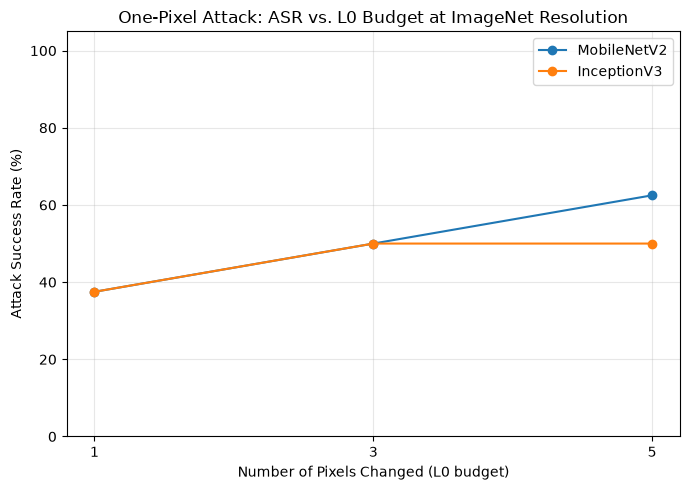

In [5]:
plt.figure(figsize=(7, 5))
for model_name in models_dict:
    plt.plot(N_PIXELS_VALUES, summary.loc[model_name], 'o-', label=model_name)
plt.xlabel('Number of Pixels Changed (L0 budget)')
plt.ylabel('Attack Success Rate (%)')
plt.title('One-Pixel Attack: ASR vs. L0 Budget at ImageNet Resolution')
plt.xticks(N_PIXELS_VALUES)
plt.ylim(0, 105)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### A Concrete Example
One successful (or, honestly, the closest-to-successful) case, zoomed in enough to see that the
found pixel is a literal single-pixel edit, not a visually obvious defect.

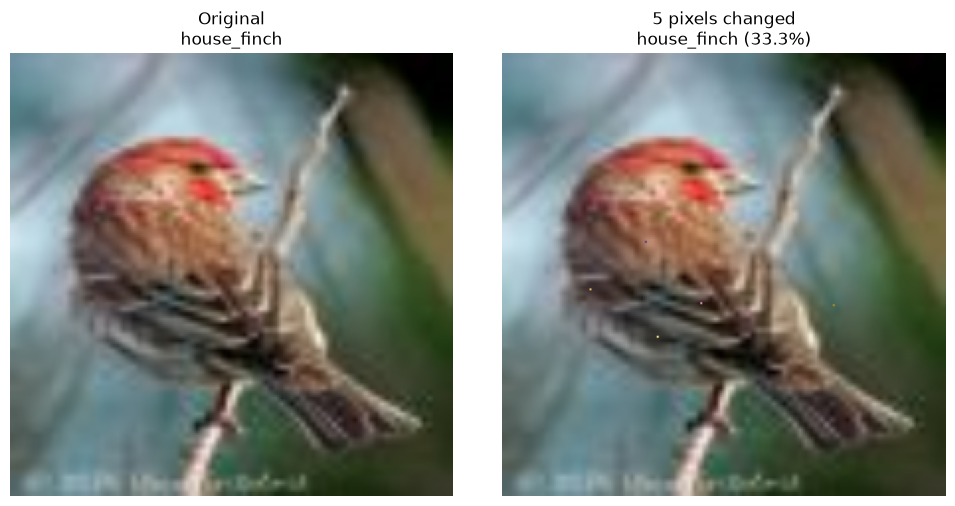

In [6]:
example_model_name = 'MobileNetV2'
m_config = models_dict[example_model_name]
raw_img = load_raw_image(image_paths[0], m_config['target_size'])
true_idx = int(np.argmax(predict(raw_img, m_config['preprocess_fn'], m_config['model'])))
true_label = m_config['decode_fn'](np.eye(1000)[true_idx][None], top=1)[0][0][1]

adv_img, adv_idx, pixel_params = one_pixel_attack(
    raw_img, true_idx, m_config['preprocess_fn'], m_config['model'], n_pixels=5, target_size=m_config['target_size']
)
adv_probs = predict(adv_img, m_config['preprocess_fn'], m_config['model'])
adv_label, adv_conf = m_config['decode_fn'](adv_probs[None], top=1)[0][0][1:3]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(raw_img.astype(np.uint8))
axes[0].set_title(f'Original\n{true_label}')
axes[0].axis('off')
axes[1].imshow(adv_img.astype(np.uint8))
axes[1].set_title(f'5 pixels changed\n{adv_label} ({adv_conf*100:.1f}%)', color='darkred' if adv_idx != true_idx else 'black')
axes[1].axis('off')
plt.tight_layout()
plt.show()